In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import numpy as np

base = r"C:\Users\Aman Jha\sannuboi\crack\crack"
img_folder = os.path.join(base, "images")
mask_folder = os.path.join(base, "masks")
os.makedirs(mask_folder, exist_ok=True)

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(root="crack", transform=None)

print("Class to index mapping:", dataset.class_to_idx)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_dataset.dataset.transform = train_tf
test_dataset.dataset.transform  = val_tf

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

train_images, train_labels = next(iter(train_loader))
test_images, test_labels   = next(iter(test_loader))

print("Train batch shape:", train_images.shape)
print("Test batch shape:", test_images.shape)


Class to index mapping: {'Negative': 0, 'Positive': 1, 'images': 2, 'masks': 3}
Train batch shape: torch.Size([16, 3, 224, 224])
Test batch shape: torch.Size([16, 3, 224, 224])


In [4]:
from PIL import Image
import os

widths, heights = [], []

folder_path = "crack"

for class_folder in os.listdir(folder_path):
    class_path = os.path.join(folder_path, class_folder)
    
    if os.path.isdir(class_path):
        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            try:
                img = Image.open(img_path)
                w, h = img.size
                widths.append(w)
                heights.append(h)
            except:
                continue

print(f"Min width: {min(widths)}, Max width: {max(widths)}")
print(f"Min height: {min(heights)}, Max height: {max(heights)}")
print(f"Average width: {sum(widths)//len(widths)}")
print(f"Average height: {sum(heights)//len(heights)}")


Min width: 227, Max width: 227
Min height: 227, Max height: 227
Average width: 227
Average height: 227


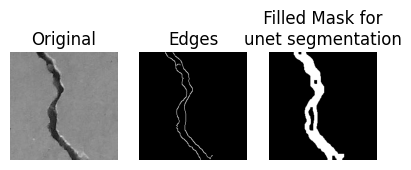

False

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "crack/positive/00003.jpg"  

img = cv2.imread(image_path, 0)

blur = cv2.GaussianBlur(img, (7,7), 0)

edges = cv2.Canny(blur, 40, 120)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
dilated = cv2.dilate(edges, kernel, iterations=2)

filled = cv2.morphologyEx(dilated, cv2.MORPH_CLOSE, kernel, iterations=3)
filled = cv2.dilate(filled, kernel, iterations=1)

num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(filled, connectivity=8)
clean_filled = np.zeros_like(filled)

min_area = 200
for i in range(1, num_labels):
    if stats[i, cv2.CC_STAT_AREA] > min_area:
        clean_filled[labels == i] = 255

# --- Show Results ---
plt.subplot(1,4,1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,4,2)
plt.title("Edges")
plt.imshow(edges, cmap='gray')
plt.axis('off')


plt.subplot(1,4,3)
plt.title(" Filled Mask for \nunet segmentation")
plt.imshow(clean_filled, cmap='gray')
plt.axis('off')

plt.show()

# ✅ Save for U-Net
cv2.imwrite("crack_seg/masks/sample.png", clean_filled)


In [26]:
import os
import cv2
import torch
from torch.utils.data import Dataset

class CrackSegDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        name_no_ext = os.path.splitext(img_name)[0]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, name_no_ext + "_mask.png")

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)

        image = image / 255.0
        mask = mask / 255.0

        image = torch.tensor(image, dtype=torch.float32).permute(2,0,1)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask


In [27]:
from torch.utils.data import DataLoader, random_split

dataset = CrackSegDataset(
    image_dir=r"C:\Users\Aman Jha\sannuboi\crack\crack\images",
    mask_dir=r"C:\Users\Aman Jha\sannuboi\crack\crack\masks"
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dd, val_dd = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dd, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dd, batch_size=4)


In [13]:
import segmentation_models_pytorch as smp
import torch.nn as nn

base_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

class UNetWithDropout(nn.Module):
    def __init__(self, model, p=0.3):
        super().__init__()
        self.model = model
        self.dropout = nn.Dropout2d(p)

    def forward(self, x):
        features = self.model.encoder(x)

        features = list(features)
        features[-1] = self.dropout(features[-1])

        decoder_out = self.model.decoder(features)

        out = self.model.segmentation_head(decoder_out)

        return out

model = UNetWithDropout(base_model)


In [14]:
import torch.optim as optim
import segmentation_models_pytorch as smp

loss_fn = smp.losses.DiceLoss(mode="binary")
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [15]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

epochs = 10
loss_values = []

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks  = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks  = masks.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, masks)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")




Epoch 1/10 | Train Loss: 0.7070 | Val Loss: 0.5955
Epoch 2/10 | Train Loss: 0.5352 | Val Loss: 0.4515
Epoch 3/10 | Train Loss: 0.4243 | Val Loss: 0.3389
Epoch 4/10 | Train Loss: 0.3458 | Val Loss: 0.3238
Epoch 5/10 | Train Loss: 0.2753 | Val Loss: 0.2275
Epoch 6/10 | Train Loss: 0.2456 | Val Loss: 0.1963
Epoch 7/10 | Train Loss: 0.2080 | Val Loss: 0.2172
Epoch 8/10 | Train Loss: 0.1732 | Val Loss: 0.1779
Epoch 9/10 | Train Loss: 0.1650 | Val Loss: 0.1507
Epoch 10/10 | Train Loss: 0.1607 | Val Loss: 0.1512


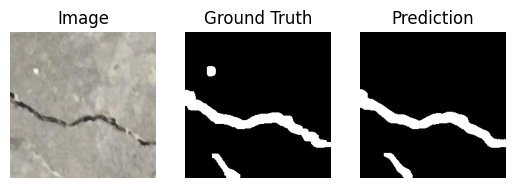

In [18]:
import matplotlib.pyplot as plt

model.eval()
img, mask = dataset[200]

with torch.no_grad():
    pred = model(img.unsqueeze(0).to(device))
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(img.permute(1,2,0))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask.squeeze(), cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred.cpu().squeeze(), cmap='gray')
plt.axis("off")

plt.show()


In [19]:
torch.save(model.state_dict(), "crack_unet.pth")


In [20]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks  = masks.to(device)

        outputs = model(images)
        preds = torch.sigmoid(outputs)
        preds = (preds > 0.5).float()

        gt_labels = (masks.sum(dim=(1,2,3)) > 0).long()  

        pred_labels = (preds.sum(dim=(1,2,3)) > 0).long()

        correct += (pred_labels == gt_labels).sum().item()
        total   += len(gt_labels)
    accuracy=correct/total
print(f"Classification Accuracy: {accuracy*100:.2f}%")


Classification Accuracy: 97.87%


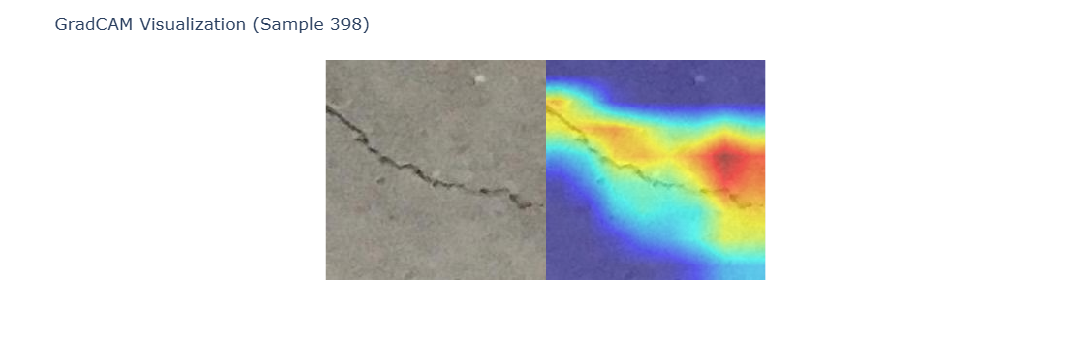

In [21]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import SemanticSegmentationTarget
import numpy as np
import plotly.express as px
import torch

def unet_gradcam(i):
    img, _ = dataset[i]

    rgb = img.permute(1,2,0).numpy()
    input_tensor = img.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(input_tensor)).cpu().squeeze().numpy()

    pred_mask = (pred > 0.5).astype(np.float32)   

    target_mask = pred_mask

    targets = [SemanticSegmentationTarget(category=0, mask=target_mask)]

    target_layers = [model.model.encoder.layer4[2]]  
    cam = GradCAM(model=model, target_layers=target_layers)

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    cam_image = show_cam_on_image(rgb, grayscale_cam, use_rgb=True)

    combined = np.hstack([rgb, cam_image/255.0])

    fig = px.imshow(combined)
    fig.update_layout(title=f"GradCAM Visualization (Sample {i})")
    fig.update_xaxes(showticklabels=False).update_yaxes(showticklabels=False)
    fig.show()


unet_gradcam(398)


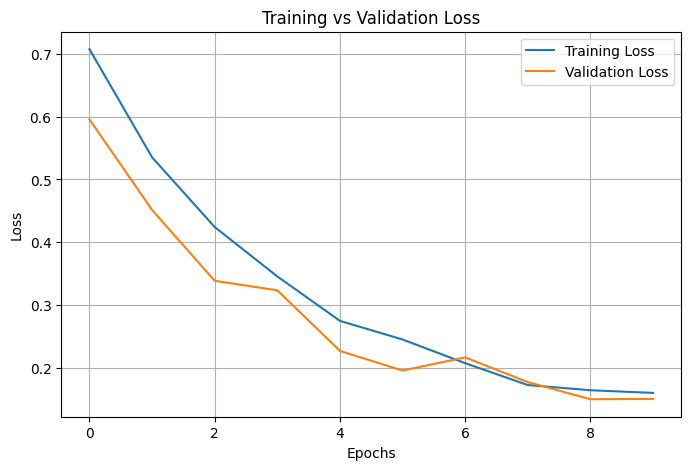

In [22]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


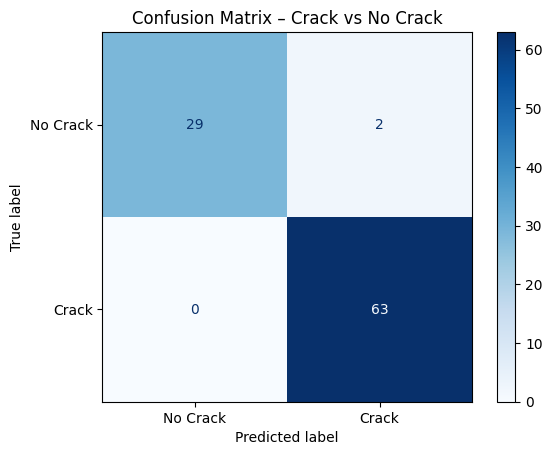

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_gts   = []

model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks  = masks.to(device)

        outputs = model(images)
        preds = torch.sigmoid(outputs)
        preds = (preds > 0.5).float()

        gt_labels = (masks.sum(dim=(1,2,3)) > 0).long().cpu().numpy()      
        pred_labels = (preds.sum(dim=(1,2,3)) > 0).long().cpu().numpy()

        all_gts.extend(gt_labels)
        all_preds.extend(pred_labels)

cm = confusion_matrix(all_gts, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Crack", "Crack"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Crack vs No Crack")
plt.show()
